# Consumo CDMX

In [108]:
import altair as alt
import contextily as cx
import numpy as np
import pandas as pd
import seaborn as sns

from datetime import timedelta
from glob import glob
from matplotlib import pyplot as plt

In [2]:
plot_width = 12
plot_height = 5
plt.rcParams['figure.figsize'] = plot_width, plot_height

* Link al notebook original:
* Link al script con la definición de funciones auxiliares:

## 1. Preparación de los datos

Se leen los archivos CSV con los datos (`data/data_1.csv`, `data/data_2.csv`, etc) y se consolidan en un único dataframe `df_h`:

In [137]:
files = glob('data/data_*.csv')
data = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)

In [4]:
print(data.dtypes)

time           object
zip_code       object
food           object
restaurants    object
hotels         object
health         object
airlines       object
services       object
goods          object
leisure        object
gasoline       object
total          object
date           object
dtype: object


In [5]:
data['date'] = pd.to_datetime(data['date'])
data['datetime'] = data['date'] + data['time'].apply(lambda x: timedelta(hours=int(x)))
data = data.drop(columns='time')

value_cols = sorted([col for col in data.columns if col not in ('zip_code', 'date', 'datetime')])

for col in value_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [6]:
cdmx = data.copy()
cdmx['zip_code'] = '00000'

data = pd.concat([data, cdmx], ignore_index=True)

In [7]:
df_h = data.copy().groupby(['zip_code', 'datetime'])[value_cols].sum().reset_index()
df_d = data.copy().groupby(['zip_code', 'date'])[value_cols].sum().reset_index()

In [8]:
print(len(df_h) -len(df_h[['zip_code', 'datetime']]))
print(len(df_d) -len(df_d[['zip_code', 'date']]))

0
0


In [9]:
def describe(df, columns=None):
    if columns is None:
        columns = df.columns
    return df[columns].describe()

def z_score(series):
    return (series - series.mean()) / series.std()

def mean_percentage_deviation(series):
    return (series - series.mean()) / series.mean()

def calculate_metric(df, group_by, value_columns, function):
    id_cols = [col for col in df.columns if col not in value_columns]
    df_left = df.copy()[id_cols]
    df_right = df.copy().groupby(group_by)[value_columns].transform(function)
    return pd.concat([df_left, df_right], axis=1)

In [ ]:
#describe(df_h, value_cols)

In [ ]:
#describe(df_d, value_cols)

In [117]:
zscore_d = calculate_metric(df_d, 'zip_code', value_cols, z_score)


In [136]:
zscore_h = calculate_metric(df_h, 'zip_code', value_cols, z_score)
zscore_h = zscore_h.query('datetime >= "2025-05-14T00:00:00" and datetime <= "2025-06-01T23:00:00"')
zscore_h['datetime'] = zscore_h['datetime'].apply(lambda x: x.isoformat() + 'Z')
zscore_h.round(4).to_csv('zscore_h.csv', index=False)

In [135]:
mpd_h = calculate_metric(df_h, 'zip_code', value_cols, mean_percentage_deviation)
mpd_h = mpd_h.query('datetime >= "2025-05-14T00:00:00" and datetime <= "2025-06-01T23:00:00"')
mpd_h['datetime'] = mpd_h['datetime'].apply(lambda x: x.isoformat() + 'Z')
mpd_h.round(4).to_csv('mpd_h.csv', index=False)

In [115]:
alt.Chart(zscore_d.query('zip_code == "15620"')).mark_bar().encode(
    x="date:T",
    y="total:Q",
).properties(
    width=800,
    height=400
)

alt.Chart(...)

In [14]:
import geopandas as gpd

In [81]:
cdmx = gpd.read_file('cdmx.json').rename(columns={'d_cp': 'zip_code'}).to_crs('EPSG:3857')
cdmx['centroid'] = cdmx['geometry'].centroid

In [82]:
adj_zipcodes = {}

for index, row in cdmx.iterrows():   
    adjacent = cdmx[~cdmx.geometry.disjoint(row.geometry)].zip_code.tolist()
    adjacent = [zip_code for zip_code in adjacent if row.zip_code != zip_code]
    adj_zipcodes[row.zip_code] = adjacent

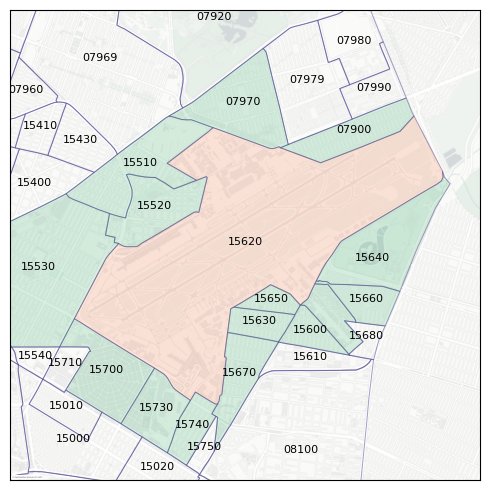

In [106]:
def plot_map(gdf, zip_code, delta, adj_1=False, adj_2=False):
    edge_color = (0.28, 0.24, 0.55, 0.5)
    center_color = (1, 0.5, 0.31, 0.2)
    adjacent_1_color = (0.24, 0.7, 0.44, 0.2)
    adjacent_2_color = (0.24, 0.7, 0.44, 0.2)
    centroid = gdf.query(f'zip_code == "{zip_code}"')['centroid']
    x, y = centroid.x.iloc[0], centroid.y.iloc[0]
    ax = gdf.plot(figsize=(plot_height, plot_height), facecolor=(0, 0, 0, 0), edgecolor=edge_color, linewidth=0.7)
    gdf.query(f'zip_code == "{zip_code}"').plot(figsize=(plot_height, plot_height), facecolor=center_color, linewidth=0, ax=ax)
    for zc in adj_zipcodes[zip_code]:
        gdf.query(f'zip_code == "{zc}"').plot(figsize=(plot_height, plot_height), facecolor=adjacent_1_color, linewidth=0, ax=ax)
    ax.set_xlim(x-delta, x+delta)
    ax.set_ylim(y-delta, y+delta)
    ax.xaxis.set_tick_params(labelbottom=False, bottom=False)
    ax.yaxis.set_tick_params(labelleft=False, left=False)
    for idx, row in gdf.iterrows():
        plt.annotate(text=row['zip_code'],
                     xy=(row['centroid'].x, row['centroid'].y),
                     horizontalalignment='center',
                     fontsize=8,
                     transform=ax.transAxes, clip_on=True)
    cx.add_basemap(ax, crs=gdf.crs, source=cx.providers.CartoDB.PositronNoLabels, attribution_size=0, zoom=15)
    plt.tight_layout()
    plt.show()

plot_map(cdmx, '15620', 3200)